In [17]:
from numpy import *
import matplotlib.pyplot as plt

In [34]:
datax = genfromtxt('maps\MAP_2021-08-19T08-47-48.csv',skip_header = 2,delimiter =',',encoding = 'cp850') #L6x data
data = genfromtxt('maps\MAP_2021-08-19T09-45-06.csv',skip_header = 2,delimiter =',',encoding = 'cp850') #L6 data

phi = data[:,2] -180#-180 because here still old coordinate system in the data
phi = phi * 2*pi / 360
rho = data[:,1]
z = data[:,3]

l = min( len(phi), len(datax[:,2])) #it seems that some mapping more data point were collected

Bphi = data[:l,4]
Brho = data[:l,8]
Bz = data[:l,6]

Bphix = datax[:l,4]
Brhox = datax[:l,8]
Bzx = datax[:l,6]


# Taking the sum

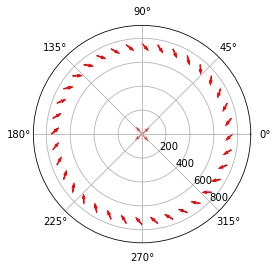

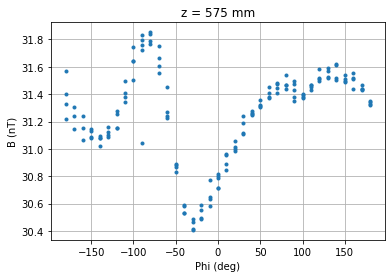

In [61]:
Sphi = Bphi+Bphix
Srho = Brho+Brhox
Sz   = Bz  +Bzx

ax = plt.subplot(111, polar=True);

#for quiver we need to convert (r,phi)- (x,y)
Sx = Srho*cos(phi) - Sphi*sin(phi)
Sy = Srho*sin(phi) + Sphi*cos(phi)

#adding the refrence vector to the plot  #ToDo
q = ax.quiver(phi,rho,Sx,Sy, color='r')
#p = ax.quiver([0],[0],[0],[-], color='g')

#ax.set_rmax(1.2) #arrow size scales with height coordinate system 
#ax.set_rmin(0.8)
ax.set_rmax(rho.max()*1.2)
#ax.set_rticks([0.9,1,1.1])
ax.set_rlabel_position(315)
ax.grid(True)
plt.show()


Stot = sqrt( Sx**2 + Sy**2 + Sz**2)

plt.title('z = 575 mm')
plt.plot( phi/(2*pi) *360 ,Stot,'.' );
plt.grid(True)
#plt.legend(loc='best')
plt.ylabel(r'$B_{tot}$ (nT)')
plt.xlabel(r'Phi (deg)');

# Taking the Difference

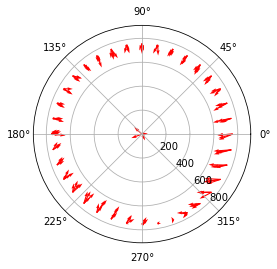

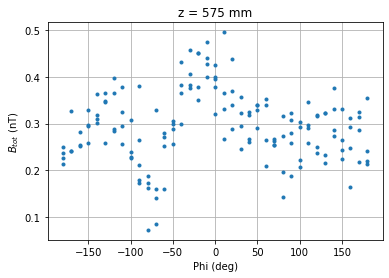

In [63]:
Dphi = Bphi-Bphix
Drho = Brho-Brhox
Dz   = Bz  -Bzx

ax = plt.subplot(111, polar=True);

#for quiver we need to convert (r,phi)- (x,y)
Dx = Drho*cos(phi) - Dphi*sin(phi)
Dy = Drho*sin(phi) + Dphi*cos(phi)

#adding the refrence vector to the plot  #ToDo
q = ax.quiver(phi,rho,Dx,Dy, color='r')
#p = ax.quiver([0],[0],[0],[-], color='g')

#ax.set_rmax(1.2) #arrow size scales with height coordinate system 
#ax.set_rmin(0.8)
ax.set_rmax(rho.max()*1.2)
#ax.set_rticks([0.9,1,1.1])
ax.set_rlabel_position(315)
ax.grid(True)
plt.show()


Dtot = sqrt( Dx**2 + Dy**2 + Dz**2)

plt.title('z = 575 mm')
plt.plot( phi/(2*pi) *360 ,Dtot,'.' );
plt.grid(True)
#plt.legend(loc='best')
plt.ylabel(r'$B_{tot}$ (nT)')
plt.xlabel(r'Phi (deg)');